# Training Problems and Solutions

## When more practice does not seem to help

Imagine teaching a small machine to predict a sensor reading from a position on a track. It sees examples, makes guesses, measures mistakes, and changes its adjustable numbers. Yet something looks wrong.

Perhaps the mistakes get bigger after every update. Perhaps the model draws a straight line through a curved pattern. Or perhaps it follows the training dots beautifully but makes worse guesses at other positions.

Those are different problems. “Train for longer” cannot be the answer to all of them. We need to notice the symptom, trace a likely cause, and try a repair whose effect we can measure.

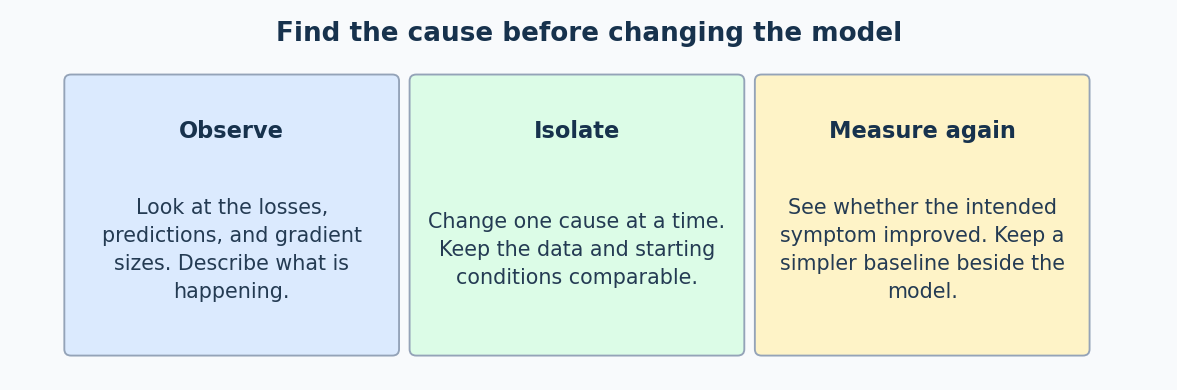

A **parameter** is an adjustable number such as a weight or bias. A **loss** scores the difference between predictions and targets. A **gradient** measures the local sensitivity of loss to parameters, and an **optimizer** uses gradients to change them. These pieces can all run correctly while the overall learning behavior is disappointing.

The [code companion](10_Training_Problems_and_Solutions.ipynb) uses tiny CPU-friendly demonstrations to make the causes visible. Every example is generated locally. The goal is to understand evidence and repairs, not to promise that one setting fixes every network.

## Start with the problem this lesson solves

When an ANN learns poorly, “add more layers” is not a diagnosis. Exploding loss, high training loss, and low training loss with poor validation performance are different symptoms. We need to trace the mechanism so the repair addresses the cause.

The examples below separate three failures: unstable numerical steps, insufficient representational capacity, and fitting noise. Each can prevent the network from solving the intended prediction problem even when the training code runs.

## Trace a failure before choosing a repair

**An oversized update caused by input scale.** In a one-example miniature, predict $\hat y=wx$ for input $x=1000$ and target two. Start $w=0$ and use $L=\tfrac12(\hat y-2)^2$. Prediction is zero, error is $-2$, and loss is two. The gradient is error times input: $(-2)(1000)=-2000$.

At learning rate $0.1$, $w'=0-0.1(-2000)=200$. New prediction is $200(1000)=200,000$, error is $199,998$, and loss is $\tfrac12(199,998)^2=19,999,600,002$. The large numerical input multiplies the gradient, then multiplies the changed weight again during prediction.

**Repair the scale:** use $x'=x/1000=1$, with a newly initialized weight $a=0$. The target stays two. Its gradient is $(-2)(1)=-2$, so $a'=0.2$, prediction becomes $0.2$, and loss becomes $\tfrac12(-1.8)^2=1.62$. The same rate now gives a useful step. The fitted weights have different units: equivalent predictions satisfy $a=1000w$.

**Alternatively repair the step:** keep $x=1000$ but use rate $10^{-7}$. Then $w'=0.0002$, prediction is $0.2$, and loss is again $1.62$. We have demonstrated the mechanism, not a universal choice of learning rate.

**A different failure: the wrong function family.** For targets $y=x^2$ at $x=[-1,0,1]$, labels are $[1,0,1]$. A line $ax+b$ fitting both outer points must satisfy $-a+b=1$ and $a+b=1$, forcing $a=0,b=1$; it then predicts one at zero instead of zero. No optimizer can remove this contradiction while staying within straight lines. A designed feature $x^2$ solves it directly, or a nonlinear ANN can learn a suitable approximation.

**A third failure: learning the noise.** Suppose training MSE falls from $0.10$ to $0.01$, but validation MSE rises from $0.12$ to $0.30$. The later state fits training data better yet predicts separate examples worse. Keeping the earlier checkpoint addresses model selection; scaling inputs is not an explanation for this particular evidence. These numbers are an illustrative diagnostic, not a saved training result.

## Why understanding the cause changes the remedy

Use scaling or a smaller rate when updates are numerically unstable. Improve features or model capacity when the available function family cannot express the pattern. Consider more representative data, regularization, or earlier checkpoints when generalization deteriorates.

Other mechanisms have equally concrete signs: a negative ReLU score passes zero gradient along that path; repeated small derivatives can diminish gradients; repeated large ones can amplify them. Clipping limits gradient magnitude but does not repair incorrect labels or an unsuitable model. A tiny-batch fit can verify that a basic learning path works, while validation is still needed to judge usefulness.

## Describe the symptom before picking a remedy

Start by separating three patterns that can otherwise look like “the model is bad.”

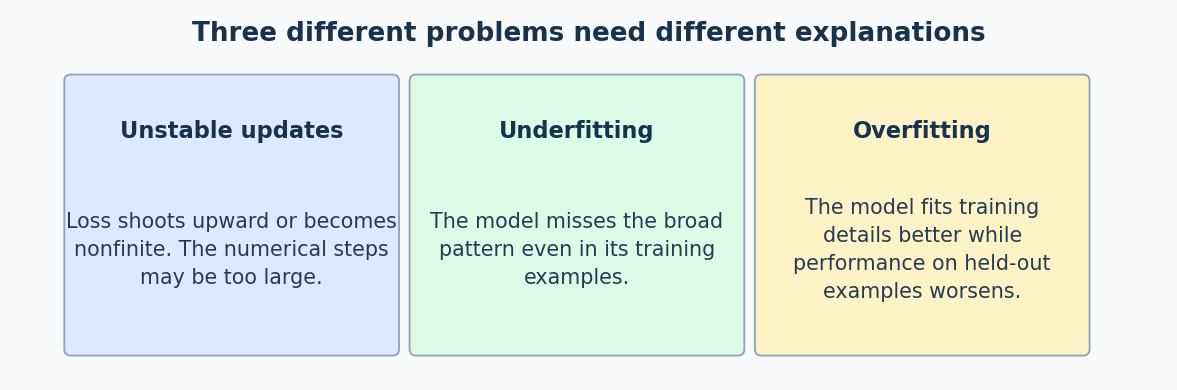

| What we observe | A possible explanation | A useful first comparison |
| --- | --- | --- |
| Loss grows rapidly after updates | Steps are too large for the scale of this calculation | Reduce the rate or inspect input scale |
| Training predictions miss the broad pattern | The model or features cannot represent it, or learning has not succeeded | Compare with a known suitable simple model |
| Training improves while validation worsens | The model may be fitting training-specific noise | Compare earlier and later saved predictions |

**Underfitting** means the learned model misses important structure, including in its training examples. **Overfitting** means fitting training-specific details in a way that harms performance on other examples.

These are clues, not automatic diagnoses. A high training loss can also come from wrong labels or a disconnected gradient path. A noisy validation point can fluctuate without proving overfitting. Looking at predictions and intermediate values helps us distinguish the stories.

## An update can be too large even with an ordinary-looking rate

Consider one weight $w$ predicting $\hat y=wx$. The input is $x$, the target is $y$, and the hat marks an estimate. Use half the squared error:

$$L=\tfrac12(wx-y)^2.$$

Its gradient with respect to the weight is $(wx-y)x$: the prediction error multiplied by the input. A basic update subtracts the learning rate times that gradient.

Suppose the same position is written as one in a large unit or one thousand in a smaller unit. The target remains two. At weight zero, both predictions are zero, but the gradients are very different.

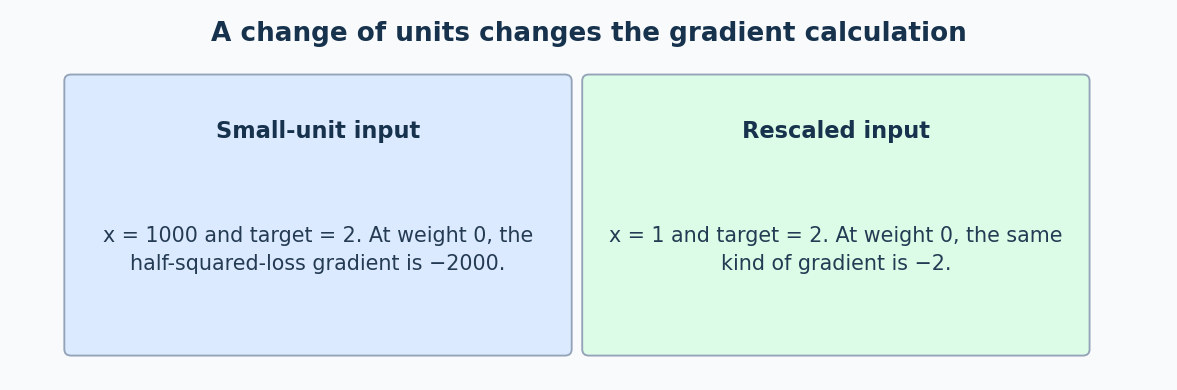

| Input | Initial error | Weight gradient | New weight with rate 0.1 | New prediction |
| --- | --- | --- | --- | --- |
| 1 | -2 | -2 | 0.2 | 0.2 |
| 1000 | -2 | -2000 | 200 | 200000 |

The huge prediction is not evidence that the target is impossible. The numerical step is badly matched to the input scale. Different units also require different final weights: weight two fits input one, while weight $0.002$ fits input one thousand.

## Repair the scale or the step, then compare again

The companion fits a one-weight model to several positions. It compares raw inputs multiplied by a thousand, rescaled inputs, and raw inputs with a much smaller learning rate. All begin at weight zero.

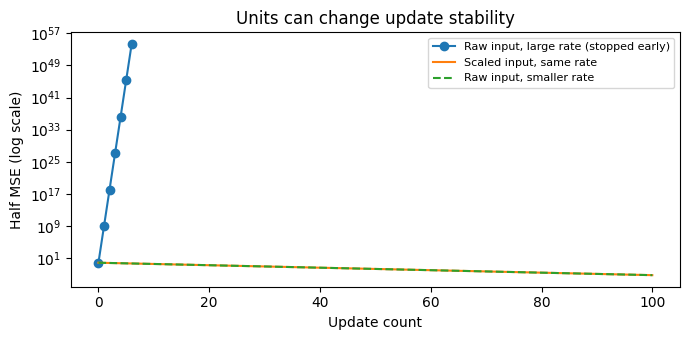

The vertical axis is logarithmic: equal vertical distances mean equal multiplication factors in loss. The unstable run stops after a few finite steps, before numerical overflow. The two stable curves overlap because their parameterizations and rates produce matching predictions in this example.

| Run | Result in the saved demonstration |
| --- | --- |
| Raw input, learning rate 0.1 | Loss grows from about 0.701 to $2.402\times10^{54}$ |
| Input divided by a thousand, learning rate 0.1 | Loss falls to about 0.000559 |
| Raw input, learning rate $10^{-7}$ | Loss falls to the same value |

The squared-loss curvature scales with the square of the input scale, which explains the million-fold rate adjustment here. This exact relationship belongs to the one-weight example; real networks need their own diagnosis.

A common general technique is **standardization**: subtract a feature's training-set mean and divide by its training-set standard deviation. The mean describes its center; the standard deviation describes its spread. A constant feature needs special handling to avoid division by zero. Apply those same stored training statistics to validation and test examples. Computing them from all groups would leak information from held-out data into preparation.

Our companion uses a known unit conversion rather than fitted statistics. Either way, scaling changes the numerical problem; it does not add information to the data or guarantee successful learning.

## Give the model a pattern it can actually represent

Now the clean sensor rule is $y=x^2$: square the position. Positions on either side of zero give positive readings, making a bowl. We add a little noise to imitate imperfect measurements.

A model restricted to $\hat y=ax+b$ draws a straight line. The weights can tilt or lift it, but no choice makes it trace a bowl across the whole range.

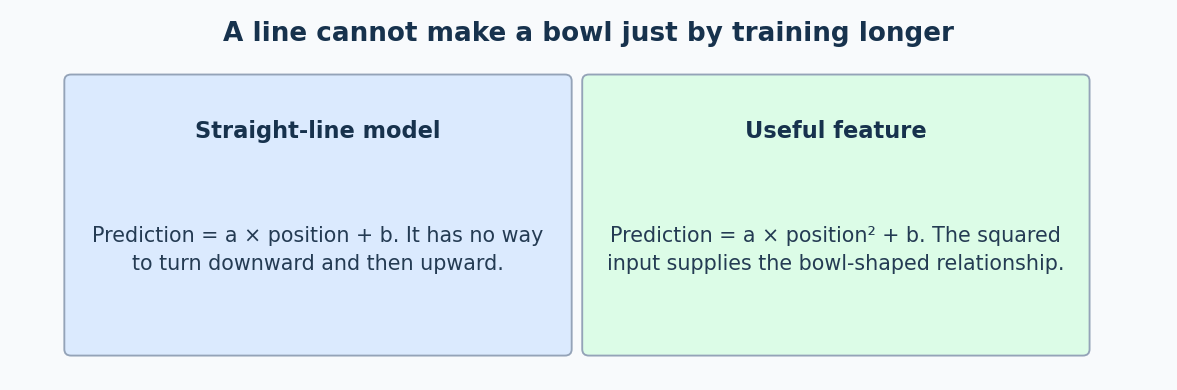

| Position | Squared position | What the shape requires |
| --- | --- | --- |
| -1 | 1 | High on the left |
| 0 | 0 | Low in the middle |
| 1 | 1 | High on the right |

The companion fits the best squared-error straight line directly, using **least squares**, a method for finding the coefficients minimizing squared error. That removes “the optimizer simply needs more steps” as an explanation for this line's limitation.

A simple repair is to supply the squared position as a feature: $\hat y=ax^2+b$. It is still linear in its adjustable coefficients $a,b$, but curved as a function of position. Validation MSE falls from about $0.12494$ for the straight line to $0.06460$ for this feature-based model in the saved run.

A neural network with nonlinear hidden layers can also represent curved relationships. More flexibility is useful when the current representation is inadequate, but a useful designed feature can be an easier solution. Increasing model size should follow evidence of a capacity problem rather than being the first response to every poor result.

## Keep examples for diagnosis separate from examples for fitting

The curved demonstration uses sixteen noisy training pairs and one hundred separate validation pairs. Both follow the same clean rule, with independently generated noise.

The noise has mean zero and standard deviation $0.22$. It can push a reading above or below the clean curve. That standard deviation describes its spread, not a fixed error added to every reading.

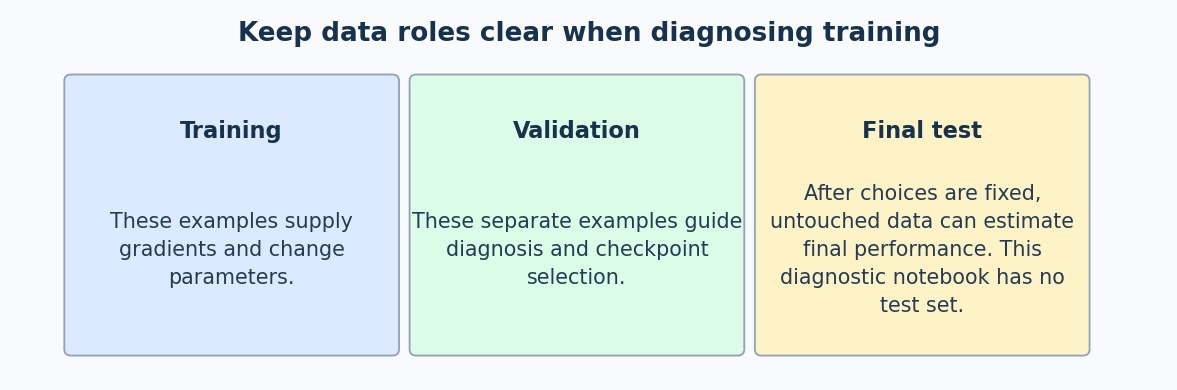

Only training pairs supply parameter gradients. Validation pairs measure the model without changing its weights. Because we use their results to choose a saved model and inspect repairs, they are part of our decision process.

This notebook deliberately has no final test group. Its goal is diagnosis, so we report **validation** results honestly rather than relabeling them as final performance. In a completed application, fix those choices before evaluating untouched test data.

The model never receives the clean formula as its target during training. We know it because we generated the examples, and can draw it afterward to explain what the noise looks like.

## Watch a flexible network start fitting the noise

Our network has two hidden layers with thirty-two units each. A hidden unit combines values with weights and a bias. **Tanh** then bends its response smoothly, allowing the network as a whole to represent curves.

The network makes full-batch Adam updates: every update uses all sixteen training examples. **Adam** is an optimizer that keeps recent gradient direction and size records to scale its moves. Using a fixed batch makes the learning curves easier to read here.

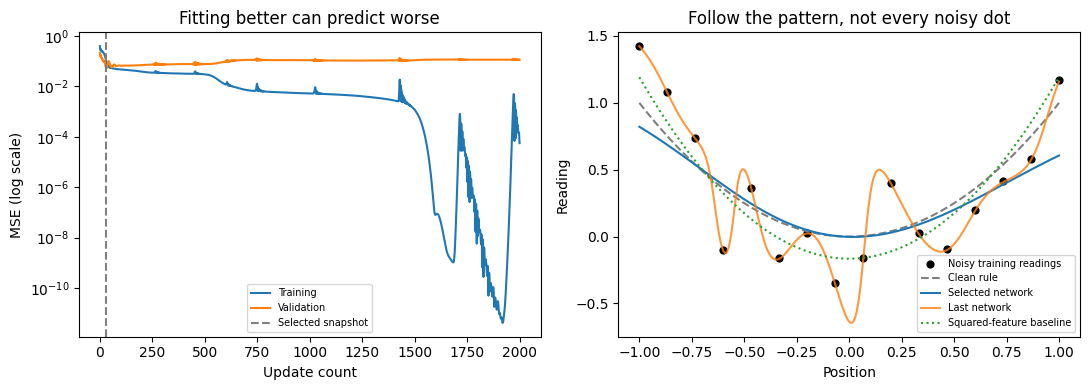

On the left, training error continues downward while validation error eventually worsens. On the right, the later network bends around individual training readings more strongly. Those dots include random noise, so passing close to all of them need not reveal the underlying relationship.

| State in the saved run | Training MSE | Validation MSE |
| --- | --- | --- |
| Selected snapshot at update 30 | Higher than the final training loss | About 0.052480 |
| Final state at update 2000 | About 0.000056 | About 0.113850 |

The later state wins at matching familiar targets but loses on validation. This is a concrete example of overfitting. Noise creates irreducible uncertainty for fresh observations in expectation, but its variance is not an exact lower bound on one finite sample's measured loss.

## Keep useful learning without keeping every later change

The companion saves an independent copy of model parameters whenever validation loss improves. After training finishes, it restores the best copy. A **checkpoint** is such a saved state; a deep copy prevents later updates from changing the saved values.

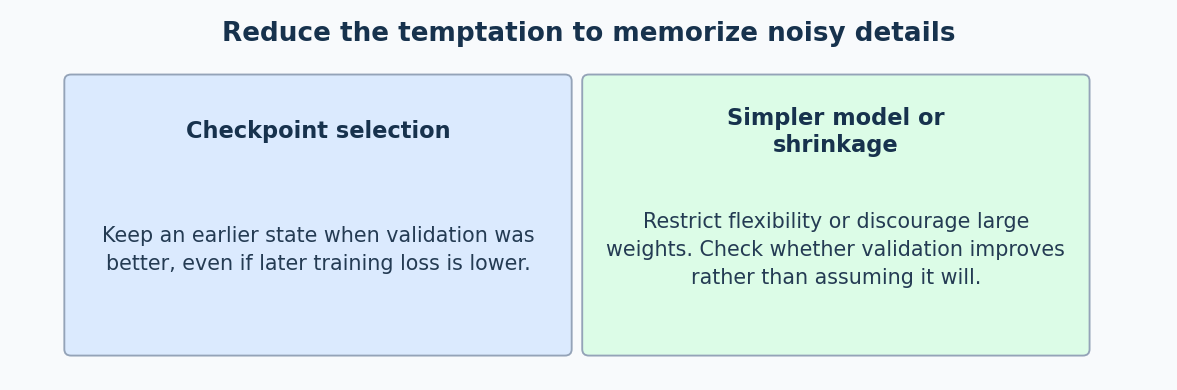

We intentionally complete the fixed update budget so we can see overfitting. This is **checkpoint selection**, not **early stopping**. Early stopping would actually end training after a chosen rule says progress has stalled, often after several validation measurements without improvement. That waiting allowance is sometimes called patience.

Other possible repairs change how easily the model can fit noise:

| Possible repair | Why it might help | What still needs checking |
| --- | --- | --- |
| Fewer hidden units or a simpler feature-based model | Restrict unnecessary flexibility | The broad pattern must remain representable |
| Weight decay | Discourage large weights during fitting | Too much shrinkage can cause underfitting |
| More representative labeled examples | Give more evidence about the real relationship | More copies of biased or wrong data may not help |
| Dropout | Randomly remove some hidden activations during training, reducing reliance on particular combinations | Its rate and evaluation behavior must be appropriate |

**Regularization** is the broad idea of discouraging overly flexible fits in pursuit of better performance on new data. No regularizer knows which target is noise. Use validation evidence, and remember that repeated tuning can also overfit a small validation group.

Dropout and weight decay are described here as alternatives, not experiments performed by this companion. Their benefits are not established by our checkpoint result.

## Trace a gradient that becomes too small or too large

Even a suitable model can have trouble receiving useful gradient signals. The chain rule multiplies local sensitivities along a computation path.

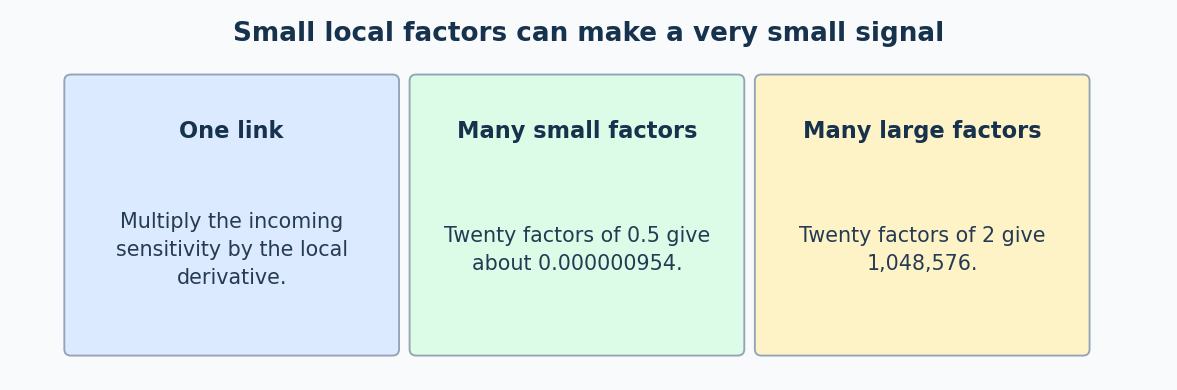

Suppose each link multiplies its input by one-half. Its local derivative is also one-half. After twenty links, the derivative of the output with respect to the starting value is:

$$\underbrace{0.5\times0.5\times\cdots\times0.5}_{\text{twenty factors}}=0.5^{20}\approx0.000000954.$$

Replace each factor with two and the derivative is $2^{20}=1{,}048{,}576$. These are isolated chain-rule calculations, not predictions that every deep network behaves this way.

**Vanishing gradients** are signals that shrink so much along paths that some parameters receive very small updates. **Exploding gradients** grow so large that updates can become unstable. Network weights and activation slopes both affect these products.

Inspect gradient magnitudes across layers before choosing a remedy. Suitable initial weight scales, activation choices, normalization, and shorter additive paths can change how signals travel. A **residual connection**, for example, adds an input to a transformed version of itself, creating a direct path for part of the signal. These choices change the model; they are not substitutes for checking the loss and data first.

## Limit an oversized gradient without pretending to fix its cause

**Gradient clipping** limits the size of a gradient before the optimizer uses it. A common size measure is its Euclidean norm: square the entries, sum them, then take a square root.

For a gradient $(30,40)$, the norm is $\sqrt{30^2+40^2}=\sqrt{2500}=50$. With a maximum norm of one, multiply every entry by $1/50$.

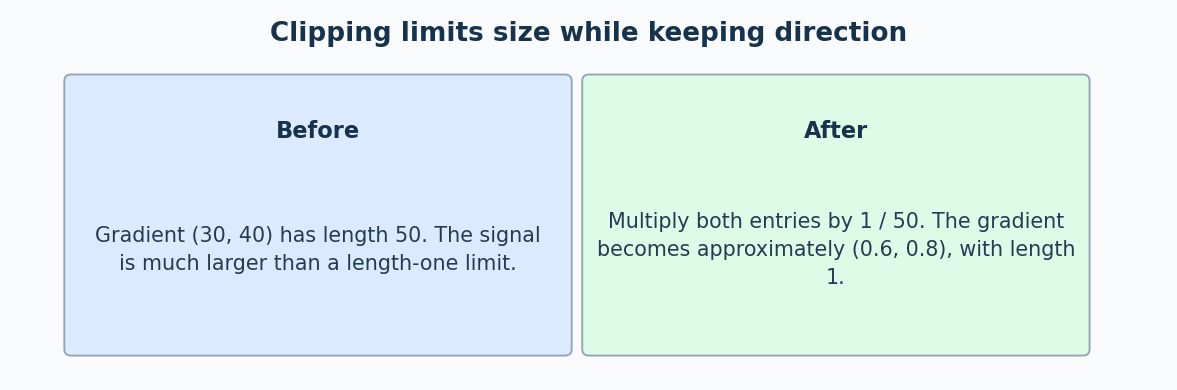

The result is approximately $(0.6,0.8)$, whose norm is one. Multiplying all entries by the same positive factor keeps the direction. The library uses a small numerical safeguard, so the returned values can differ slightly from exact decimals.

Clipping belongs after backward computes gradients and before the optimizer step. It can reduce the harm from a very large signal, but it cannot rescue a zero signal, fix incorrect labels, or make an already infinite calculation meaningful. With adaptive optimizers, the gradient norm also does not directly specify the final parameter movement because optimizer history affects the update.

The companion demonstrates the rescaling arithmetic on an explicit gradient. It does not claim that clipping trained our sensor model better.

## An inactive unit can have a zero gradient and a nonzero loss

**ReLU** returns its input when positive and zero when negative. A negative input lies on a flat part of the function: tiny changes there leave its output unchanged.

Consider a weight of minus one multiplying input one, followed by ReLU. The prediction is zero even though the target is one. Half-squared loss is $\tfrac12(0-1)^2=0.5$, but the weight gradient is zero because the path includes ReLU's zero slope.

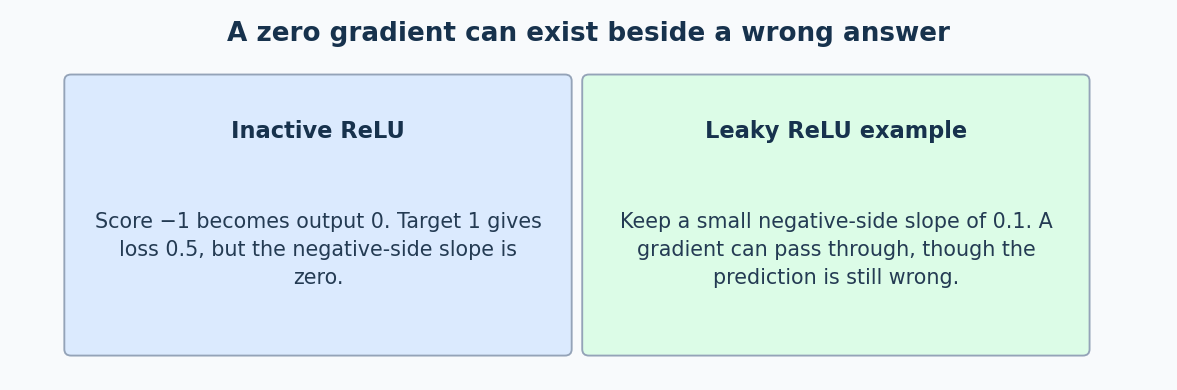

**Leaky ReLU** keeps a small negative-side slope instead. With slope $0.1$, score minus one produces prediction $-0.1$. Its loss is $0.605$, and its weight gradient is $( -0.1-1)\times0.1\times1=-0.11$.

Notice that the immediate loss is actually larger. The distinction is that a signal now reaches the weight; that alone does not prove better final learning. Another repair might involve initialization, input scale, or the learning rate that pushed the unit into inactivity.

A unit inactive for one input is not necessarily inactive for every input. Inspect a representative batch before concluding that it never contributes.

## Confirm that the basic learning path works

Before replacing the architecture, try fitting a tiny, deliberately easy group of examples whose relationship the model can represent. If that fails, tracing the implementation may be more useful than adding layers.

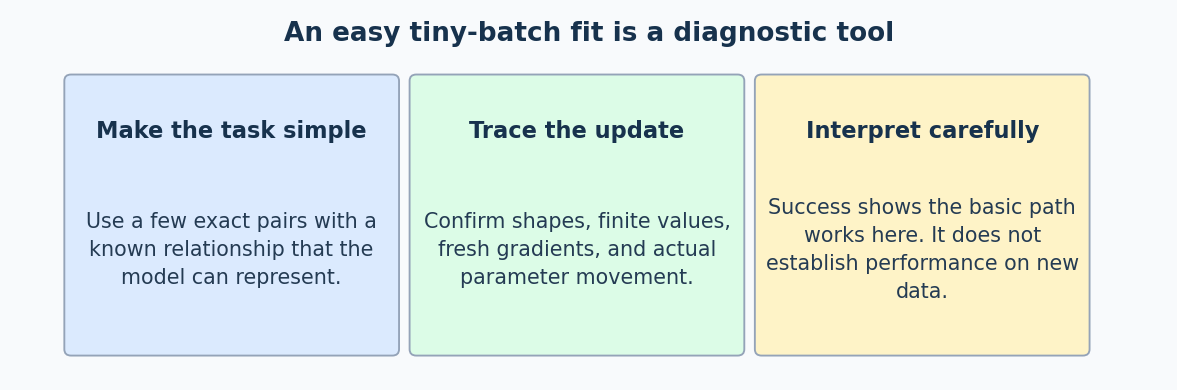

The companion uses four exact pairs with rule $y=2x+0.5$ and a one-layer linear model. This separate diagnostic reaches MSE of about $1.2\times10^{-13}$ in the saved run. That is evidence the basic mechanism works for this easy problem, not evidence about performance on unfamiliar examples.

| Place to inspect | Why it matters |
| --- | --- |
| Prediction and target shapes | Broadcasting can silently compare the wrong pairs |
| Target values and labels | A correct program can learn an incorrect target |
| Finite inputs and loss | NaN means an undefined numerical result; infinity can arise from overflow |
| Fresh gradient buffers | Old contributions otherwise accumulate into a new update |
| Gradient connections | Detaching values or converting them to plain numbers can break a required path |
| Parameter movement | Backward measures sensitivities; an optimizer step must actually apply changes |
| Training and evaluation modes | Layers such as dropout behave differently in the two modes |

If the easy fit succeeds, return to the real task and examine capacity, noise, data coverage, and the training settings.

## Match the repair to the evidence

| Demonstrated problem | Repair or diagnostic used here | What the result establishes |
| --- | --- | --- |
| Huge unstable scalar steps | Change input scale or reduce the learning rate | Both stabilize this known calculation |
| A straight line misses a bowl | Supply squared position as a feature | A suitable simple representation can help |
| Later training fits noise | Restore a validation-selected snapshot | Lower training loss was not the best selection rule |
| Signals shrink or grow along a chain | Inspect exact gradient products and clipping | Gradient magnitude has a traceable numerical cause |
| An inactive ReLU blocks a path | Compare a small negative-side slope | A nonzero signal can be restored in this isolated case |

Useful diagnosis connects a symptom to a cause and a cause to a measurable change. Keep the comparison controlled, inspect predictions as well as scores, and preserve a simple baseline.

The experiments here are intentionally small and constructed. Their purpose is to make training behavior understandable. A repair that helps one demonstration still needs evidence on the actual task, followed by evaluation on untouched data after the choices are fixed.

## Use regularization to control fit, not to hide a diagnosis

A flexible network can memorize noisy training examples. **L1 regularization** adds a weight-absolute-value penalty and can produce sparse parameter vectors; **L2** discourages large weights without specifically selecting zeros. The coefficient is a hyperparameter: too small leaves overfitting, while too large underfits.

**Dropout** samples a fresh mask during training. With drop probability $p$, surviving activations are divided by $1-p$ (inverted dropout), so the expected activation stays approximately unchanged. Calling `eval()` disables the mask. Dropout can reduce co-adaptation, but it is not automatically appropriate for every layer or tiny dataset.

**Early stopping** records the best validation score, waits through a chosen patience window, then restores that checkpoint. The test set remains untouched until the final report. The code compares regularization strengths and shows that both too little and too much capacity control can hurt validation error.